# Installation

In [2]:
#!pip install pandas matplotlib jiwer

In [1]:
import os
import re
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from jiwer import wer, cer

In [2]:
pages = [8, 9, 12, 38, 53, 78, 94, 105, 114, 115,
        210, 314, 316, 384, 457, 468, 490, 619, 615, 753]

In [3]:
model_dirs = {
    "GPT-5.4": "GPT_5.4/outputs/Experiment_1",
    "Gemini 3.1 Pro": "Gemini_3.1_Pro/outputs/Experiment_1",
    "Qwen3.5-35B-A3B": "Qwen 3.5_35B_A3B/outputs/Experiment_1",
    "PaddleOCR-VL 1.5": "PaddleOCR-VL_1.5/outputs/Experiment_1"
}

In [4]:
output_dir = "All_Results"

os.makedirs(output_dir, exist_ok=True)

print("Output directory:", output_dir)

Output directory: All_Results


In [6]:
def normalize_text(text):
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [7]:
results_exp1 = []

gold_base = "https://nlp.fi.muni.cz/projekty/ahisto/ocr-output/494/"

for model, model_dir in model_dirs.items():

    print(f"\nEvaluating {model}...")

    for p in pages:
        print(f"Evaluating page {p}...")

        gold_url = f"{gold_base}{p}.txt"
        gold_text = requests.get(gold_url).text

        pred_path = os.path.join(
            model_dir,
            f"page_{p}.txt"
        )

        with open(
            pred_path,
            "r",
            encoding="utf-8"
        ) as f:
            pred_text = f.read()

        gold_norm = normalize_text(gold_text)
        pred_norm = normalize_text(pred_text)

        # Compute metrics
        wer_score = wer(
            gold_norm,
            pred_norm
        )

        cer_score = cer(
            gold_norm,
            pred_norm
        )

        results_exp1.append({
            "Model": model,
            "Page": p,
            "WER": wer_score,
            "CER": cer_score
        })


Evaluating GPT-5.4...
Evaluating page 8...
Evaluating page 9...
Evaluating page 12...
Evaluating page 38...
Evaluating page 53...
Evaluating page 78...
Evaluating page 94...
Evaluating page 105...
Evaluating page 114...
Evaluating page 115...
Evaluating page 210...
Evaluating page 314...
Evaluating page 316...
Evaluating page 384...
Evaluating page 457...
Evaluating page 468...
Evaluating page 490...
Evaluating page 619...
Evaluating page 615...
Evaluating page 753...

Evaluating Gemini 3.1 Pro...
Evaluating page 8...
Evaluating page 9...
Evaluating page 12...
Evaluating page 38...
Evaluating page 53...
Evaluating page 78...
Evaluating page 94...
Evaluating page 105...
Evaluating page 114...
Evaluating page 115...
Evaluating page 210...
Evaluating page 314...
Evaluating page 316...
Evaluating page 384...
Evaluating page 457...
Evaluating page 468...
Evaluating page 490...
Evaluating page 619...
Evaluating page 615...
Evaluating page 753...

Evaluating Qwen3.5-35B-A3B...
Evaluating pag

# Experiment 1

In [8]:
df_exp1 = pd.DataFrame(results_exp1)

#df_exp1

## GPT 

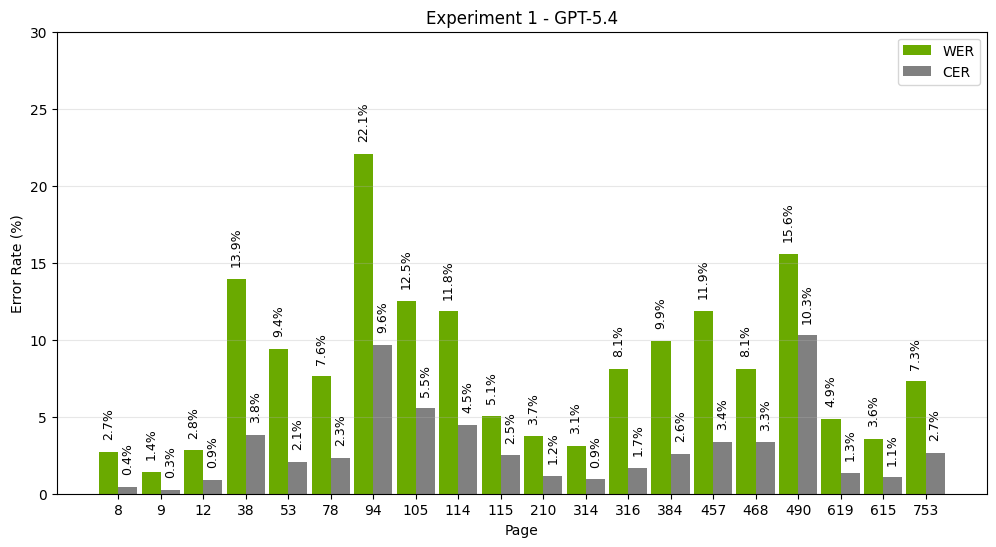

In [9]:
df_model = df_exp1[df_exp1["Model"] == "GPT-5.4"].copy()

x = np.arange(len(df_model))
width = 0.45

wer_pct = df_model["WER"] * 100
cer_pct = df_model["CER"] * 100

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x - width / 2,wer_pct,width,label="WER",color="#6AAA00")

bars2 = plt.bar(x + width / 2,cer_pct,width,label="CER",color="#808080")

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1 - GPT-5.4")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 30)
plt.yticks(np.arange(0, 31, 5))

os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_1_gpt_5_4.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

## Gemini

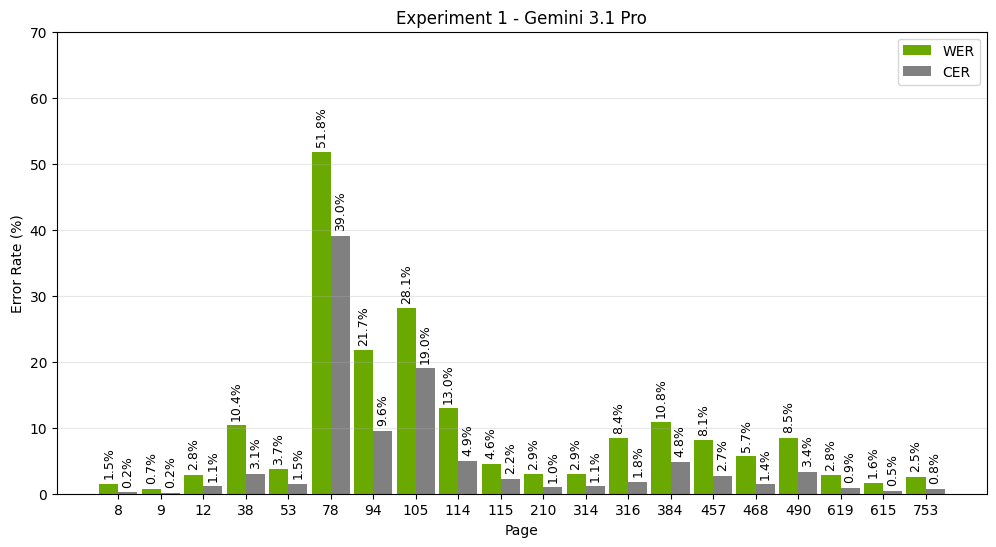

In [11]:


df_model = df_exp1[
    df_exp1["Model"] == "Gemini 3.1 Pro"
].copy()

x = np.arange(len(df_model))
width = 0.45

wer_pct = df_model["WER"] * 100
cer_pct = df_model["CER"] * 100

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width / 2,
    wer_pct,
    width,
    label="WER",
    color="#6AAA00"
)

bars2 = plt.bar(
    x + width / 2,
    cer_pct,
    width,
    label="CER",
    color="#808080"
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1 - Gemini 3.1 Pro")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 70)
plt.yticks(np.arange(0, 71, 10))

os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_1_gemini_3_1.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

## Qwen

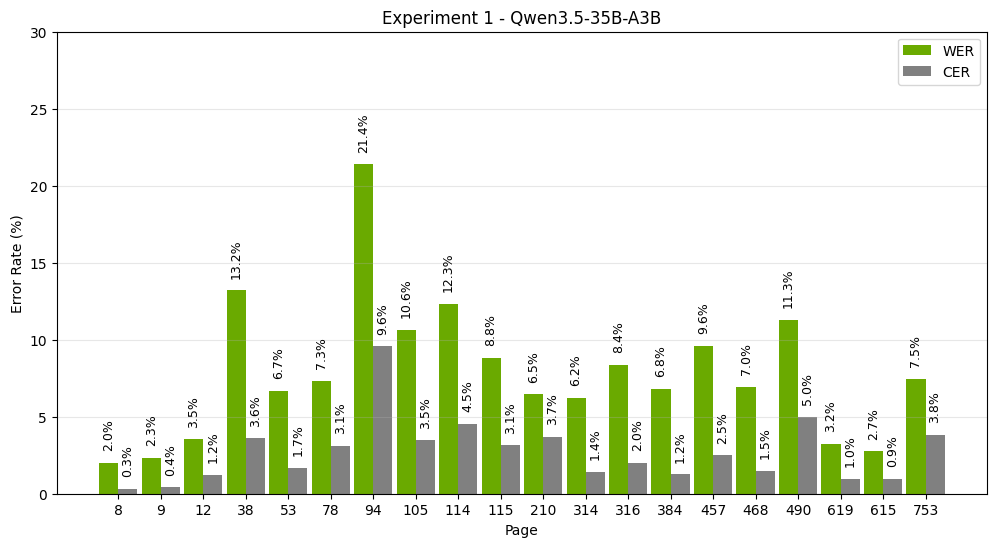

In [12]:
# With vector graphics

df_model = df_exp1[
    df_exp1["Model"] == "Qwen3.5-35B-A3B"
].copy()

x = np.arange(len(df_model))
width = 0.45

wer_pct = df_model["WER"] * 100
cer_pct = df_model["CER"] * 100

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width / 2,
    wer_pct,
    width,
    label="WER",
    color="#6AAA00"
)

bars2 = plt.bar(
    x + width / 2,
    cer_pct,
    width,
    label="CER",
    color="#808080"
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1 - Qwen3.5-35B-A3B")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 30)
plt.yticks(np.arange(0, 31, 5))

os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_1_qwen_3_5.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

## PaddleOCR-VL

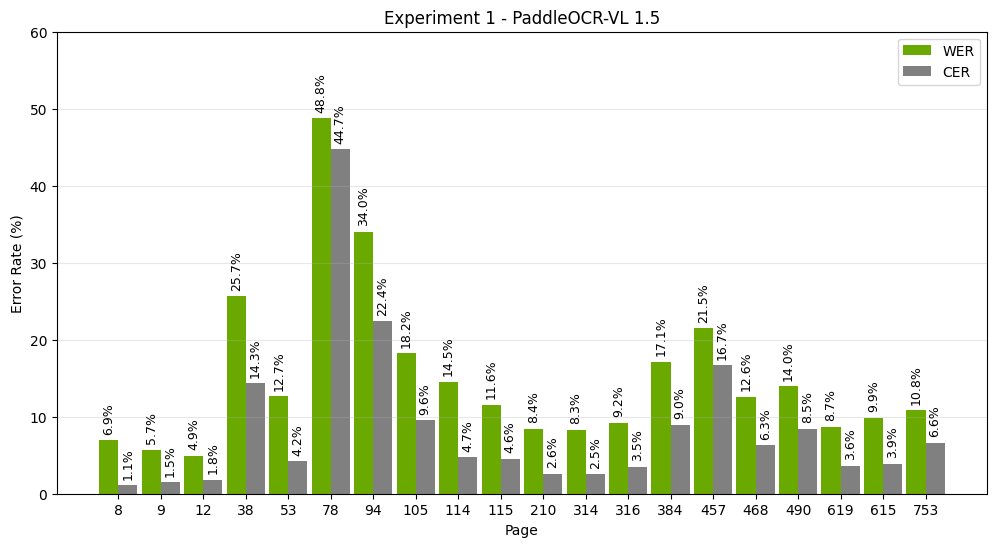

In [13]:
# With vector graphics

df_model = df_exp1[
    df_exp1["Model"] == "PaddleOCR-VL 1.5"
].copy()

x = np.arange(len(df_model))
width = 0.45

wer_pct = df_model["WER"] * 100
cer_pct = df_model["CER"] * 100

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width / 2,
    wer_pct,
    width,
    label="WER",
    color="#6AAA00"
)

bars2 = plt.bar(
    x + width / 2,
    cer_pct,
    width,
    label="CER",
    color="#808080"
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1 - PaddleOCR-VL 1.5")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 60)
plt.yticks(np.arange(0, 61, 10))

os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_1_paddleocr_vl_1_5.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

# Experiment 2

In [14]:
model_dirs_exp2 = {
    "GPT-5.4": "GPT_5.4/outputs/Experiment_2",
    "Gemini 3.1 Pro": "Gemini_3.1_Pro/outputs/Experiment_2",
    "Qwen3.5-35B-A3B": "Qwen 3.5_35B_A3B/outputs/Experiment_2",
    "PaddleOCR-VL 1.5": "PaddleOCR-VL_1.5/outputs/Experiment_2"
}

In [16]:
results_exp2 = []

gold_base = "https://nlp.fi.muni.cz/projekty/ahisto/ocr-output/494/"

for model, model_dir in model_dirs_exp2.items():

    print(f"\nEvaluating {model}...")

    for p in pages:
        print(f"Evaluating page {p}...")

        gold_url = f"{gold_base}{p}.txt"
        gold_text = requests.get(gold_url).text

        pred_path = os.path.join(
            model_dir,
            f"page_{p}.txt"
        )

        with open(
            pred_path,
            "r",
            encoding="utf-8"
        ) as f:
            pred_text = f.read()

        gold_norm = normalize_text(gold_text)
        pred_norm = normalize_text(pred_text)

        # Compute metrics
        wer_score = wer(gold_norm, pred_norm)
        cer_score = cer(gold_norm, pred_norm)

        results_exp2.append({
            "Model": model,
            "Page": p,
            "WER": wer_score,
            "CER": cer_score
        })


Evaluating GPT-5.4...
Evaluating page 8...
Evaluating page 9...
Evaluating page 12...
Evaluating page 38...
Evaluating page 53...
Evaluating page 78...
Evaluating page 94...
Evaluating page 105...
Evaluating page 114...
Evaluating page 115...
Evaluating page 210...
Evaluating page 314...
Evaluating page 316...
Evaluating page 384...
Evaluating page 457...
Evaluating page 468...
Evaluating page 490...
Evaluating page 619...
Evaluating page 615...
Evaluating page 753...

Evaluating Gemini 3.1 Pro...
Evaluating page 8...
Evaluating page 9...
Evaluating page 12...
Evaluating page 38...
Evaluating page 53...
Evaluating page 78...
Evaluating page 94...
Evaluating page 105...
Evaluating page 114...
Evaluating page 115...
Evaluating page 210...
Evaluating page 314...
Evaluating page 316...
Evaluating page 384...
Evaluating page 457...
Evaluating page 468...
Evaluating page 490...
Evaluating page 619...
Evaluating page 615...
Evaluating page 753...

Evaluating Qwen3.5-35B-A3B...
Evaluating pag

In [17]:
df_exp2 = pd.DataFrame(results_exp2)

#df_exp2.head()

## GPT

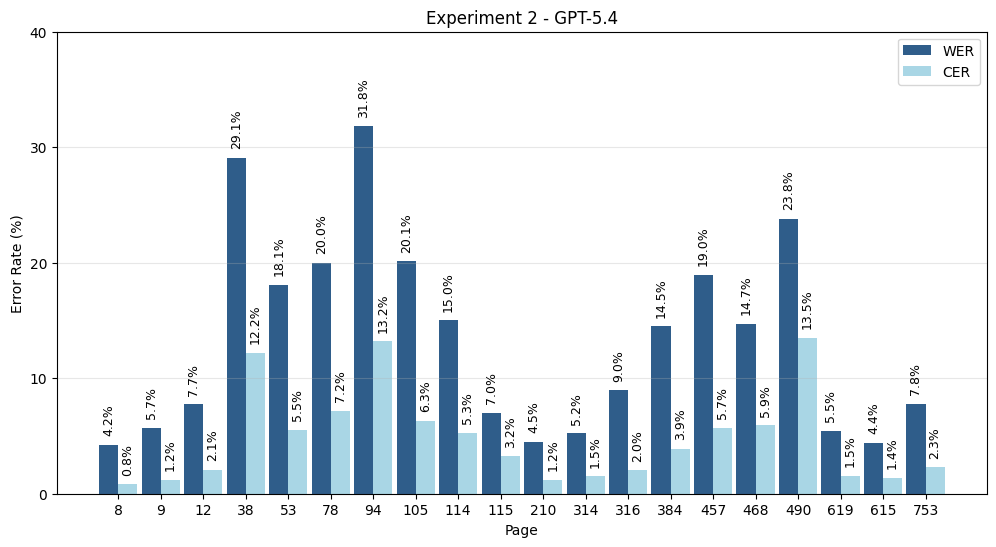

In [18]:
# With vector graphics

df_model = df_exp2[
    df_exp2["Model"] == "GPT-5.4"
].copy()

x = np.arange(len(df_model))
width = 0.45

wer_pct = df_model["WER"] * 100
cer_pct = df_model["CER"] * 100

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x - width/2,wer_pct,width,label="WER",color="#2F5D8A")
bars2 = plt.bar(x + width/2,cer_pct,width,label="CER",color="#A9D6E5")

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 2 - GPT-5.4")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 40)
plt.yticks(np.arange(0, 41, 10))

os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_2_gpt_5_4.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

## Gemini

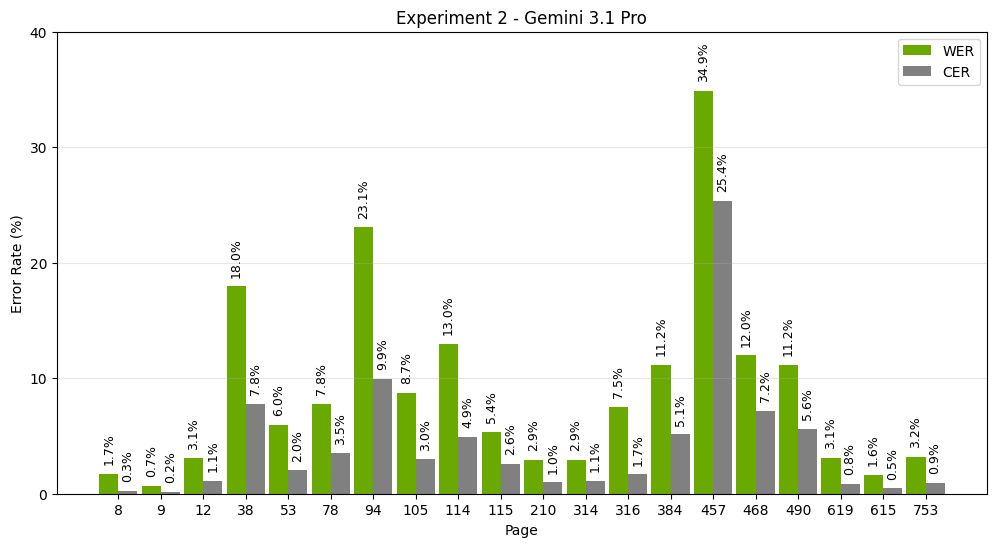

In [21]:


df_model = df_exp2[
    df_exp2["Model"] == "Gemini 3.1 Pro"
].copy()

x = np.arange(len(df_model))
width = 0.45

wer_pct = df_model["WER"] * 100
cer_pct = df_model["CER"] * 100

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width / 2,
    wer_pct,
    width,
    label="WER",
    color="#6AAA00"
)

bars2 = plt.bar(
    x + width / 2,
    cer_pct,
    width,
    label="CER",
    color="#808080"
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 2 - Gemini 3.1 Pro")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 40)
plt.yticks(np.arange(0, 41, 10))

os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_2_gemini_3_1.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

## Qwen

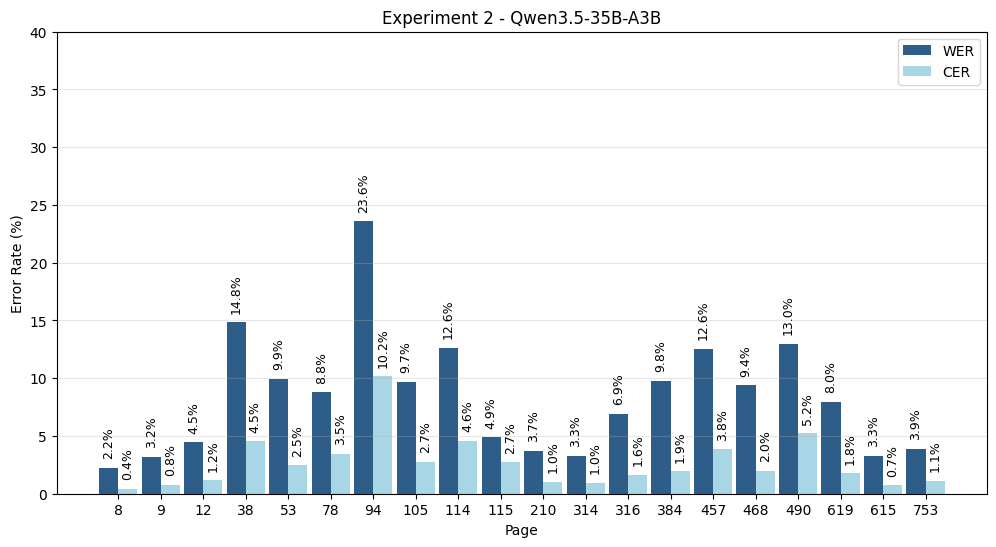

In [22]:
# With vector graphics

df_model = df_exp2[
    df_exp2["Model"] == "Qwen3.5-35B-A3B"
].copy()

x = np.arange(len(df_model))
width = 0.45

wer_pct = df_model["WER"] * 100
cer_pct = df_model["CER"] * 100

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x - width/2,wer_pct,width,label="WER",color="#2F5D8A")
bars2 = plt.bar(x + width/2,cer_pct,width,label="CER",color="#A9D6E5")

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 2 - Qwen3.5-35B-A3B")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 40)
plt.yticks(np.arange(0, 41, 5))

os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_2_qwen_3_5.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

## PaddleOCR-VL

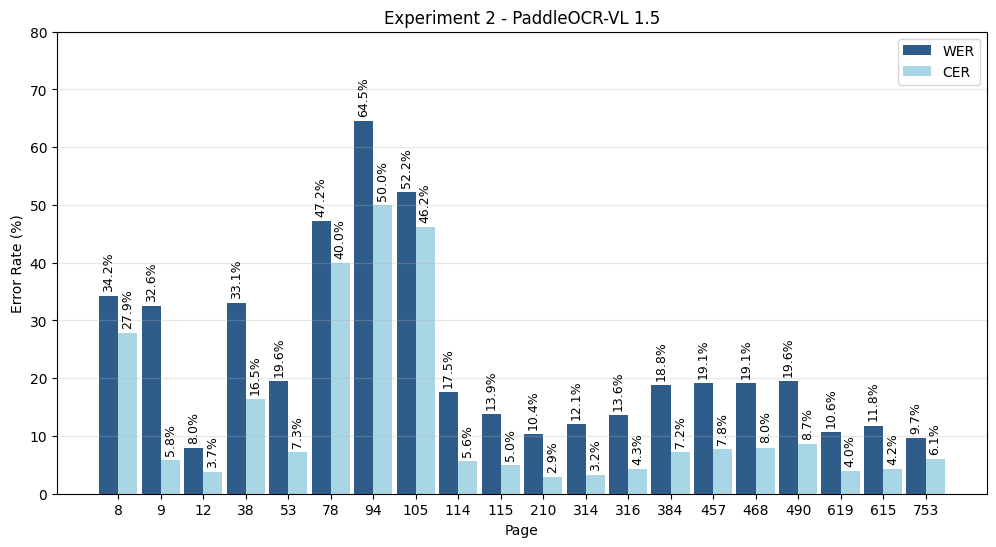

In [23]:
# With vector graphics

df_model = df_exp2[
    df_exp2["Model"] == "PaddleOCR-VL 1.5"
].copy()

x = np.arange(len(df_model))
width = 0.45

wer_pct = df_model["WER"] * 100
cer_pct = df_model["CER"] * 100

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x - width/2,wer_pct,width,label="WER",color="#2F5D8A")
bars2 = plt.bar(x + width/2,cer_pct,width,label="CER",color="#A9D6E5")

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 2 - PaddleOCR-VL 1.5")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 80)
plt.yticks(np.arange(0, 81, 10))

os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_2_paddleocr_vl_1_5.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

# Experiment 3

In [26]:
model_dirs_exp3 = {
    "GPT-5.4": "GPT_5.4/outputs/Experiment_3",
    "Gemini 3.1 Pro": "Gemini_3.1_Pro/outputs/Experiment_3",
    "Qwen3.5-35B-A3B": "Qwen 3.5_35B_A3B/outputs/Experiment_3",
    "PaddleOCR-VL 1.5": "PaddleOCR-VL_1.5/outputs/Experiment_3"
}

In [27]:
results_exp3 = []

gold_base = "https://nlp.fi.muni.cz/projekty/ahisto/ocr-output/494/"

for model, model_dir in model_dirs_exp3.items():

    print(f"\nEvaluating {model}...")

    for p in pages:
        print(f"Evaluating page {p}...")

        gold_url = f"{gold_base}{p}.txt"
        gold_text = requests.get(gold_url).text

        pred_path = os.path.join(
            model_dir,
            f"page_{p}.txt"
        )

        with open(
            pred_path,
            "r",
            encoding="utf-8"
        ) as f:
            pred_text = f.read()

        gold_norm = normalize_text(gold_text)
        pred_norm = normalize_text(pred_text)

        # Compute metrics
        wer_score = wer(gold_norm, pred_norm)
        cer_score = cer(gold_norm, pred_norm)

        results_exp3.append({
            "Model": model,
            "Page": p,
            "WER": wer_score,
            "CER": cer_score
        })


Evaluating GPT-5.4...
Evaluating page 8...
Evaluating page 9...
Evaluating page 12...
Evaluating page 38...
Evaluating page 53...
Evaluating page 78...
Evaluating page 94...
Evaluating page 105...
Evaluating page 114...
Evaluating page 115...
Evaluating page 210...
Evaluating page 314...
Evaluating page 316...
Evaluating page 384...
Evaluating page 457...
Evaluating page 468...
Evaluating page 490...
Evaluating page 619...
Evaluating page 615...
Evaluating page 753...

Evaluating Gemini 3.1 Pro...
Evaluating page 8...
Evaluating page 9...
Evaluating page 12...
Evaluating page 38...
Evaluating page 53...
Evaluating page 78...
Evaluating page 94...
Evaluating page 105...
Evaluating page 114...
Evaluating page 115...
Evaluating page 210...
Evaluating page 314...
Evaluating page 316...
Evaluating page 384...
Evaluating page 457...
Evaluating page 468...
Evaluating page 490...
Evaluating page 619...
Evaluating page 615...
Evaluating page 753...

Evaluating Qwen3.5-35B-A3B...
Evaluating pag

In [28]:
df_exp3 = pd.DataFrame(results_exp3)

#df_exp3

## GPT

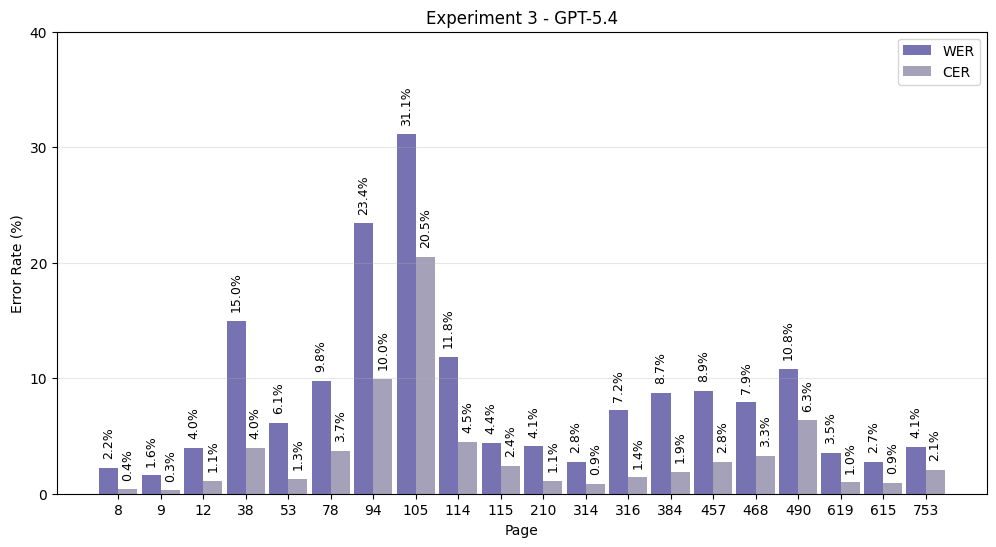

In [30]:
# With vector graphics

df_model = df_exp3[
    df_exp3["Model"] == "GPT-5.4"
].copy()

x = np.arange(len(df_model))
width = 0.45

wer_pct = df_model["WER"] * 100
cer_pct = df_model["CER"] * 100

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x - width/2,wer_pct,width,label="WER",color="#7773B2")
bars2 = plt.bar(x + width/2,cer_pct,width,label="CER",color="#A5A1B9")

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 3 - GPT-5.4")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 40)
plt.yticks(np.arange(0, 41, 10))

os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_3_gpt_5_4.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

## Gemini

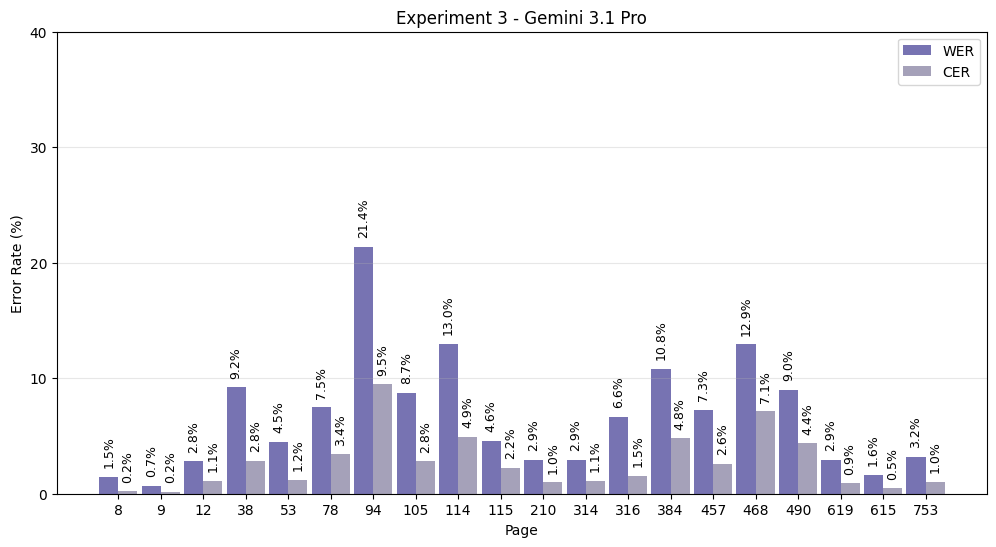

In [32]:
#with vctor graphics

df_model = df_exp3[
    df_exp3["Model"] == "Gemini 3.1 Pro"
].copy()

x = np.arange(len(df_model))
width = 0.45

wer_pct = df_model["WER"] * 100
cer_pct = df_model["CER"] * 100

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x - width/2,wer_pct,width,label="WER",color="#7773B2")
bars2 = plt.bar(x + width/2,cer_pct,width,label="CER",color="#A5A1B9")

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 3 - Gemini 3.1 Pro")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 40)
plt.yticks(np.arange(0, 41, 10))

os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_3_gemini_3_1.pdf"
    ),
    bbox_inches="tight"
)

plt.show()


## Qwen

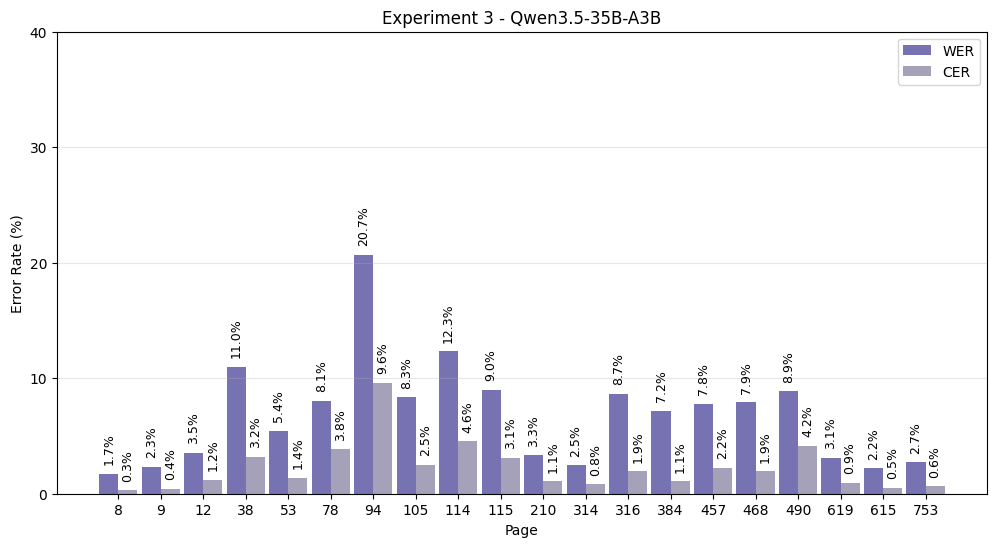

In [33]:
df_model = df_exp3[
    df_exp3["Model"] == "Qwen3.5-35B-A3B"
].copy()

x = np.arange(len(df_model))
width = 0.45

wer_pct = df_model["WER"] * 100
cer_pct = df_model["CER"] * 100

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x - width/2,wer_pct,width,label="WER",color="#7773B2")
bars2 = plt.bar(x + width/2,cer_pct,width,label="CER",color="#A5A1B9")

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 3 - Qwen3.5-35B-A3B")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 40)
plt.yticks(np.arange(0, 41, 10))

os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_3_qwen_3_5.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

## PaddleOCR - VL

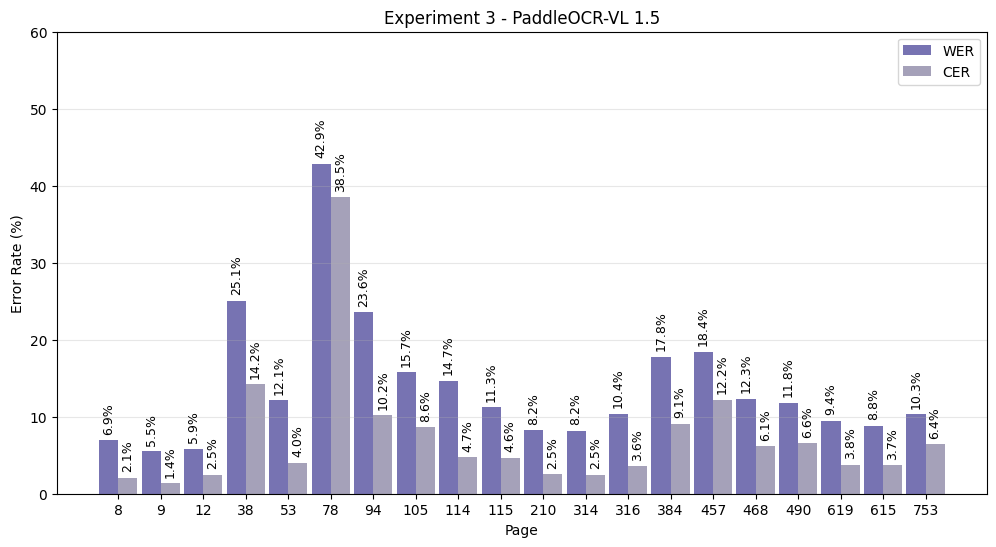

In [34]:


df_model = df_exp3[
    df_exp3["Model"] == "PaddleOCR-VL 1.5"
].copy()

x = np.arange(len(df_model))
width = 0.45

wer_pct = df_model["WER"] * 100
cer_pct = df_model["CER"] * 100

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x - width/2,wer_pct,width,label="WER",color="#7773B2")
bars2 = plt.bar(x + width/2,cer_pct,width,label="CER",color="#A5A1B9")

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 3 - PaddleOCR-VL 1.5")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 60)
plt.yticks(np.arange(0, 61, 10))

os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_3_paddleocr_vl_1_5.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

# Mean WER and CER

In [35]:
mean_exp1 = (
    df_exp1
    .groupby("Model")[["WER", "CER"]]
    .mean()
    .reset_index()
)

mean_exp1

,Model,WER,CER
0,GPT-5.4,0.082751,0.030178
1,Gemini 3.1 Pro,0.096264,0.049537
2,PaddleOCR-VL 1.5,0.151810,0.086059
3,Qwen3.5-35B-A3B,0.078677,0.027062


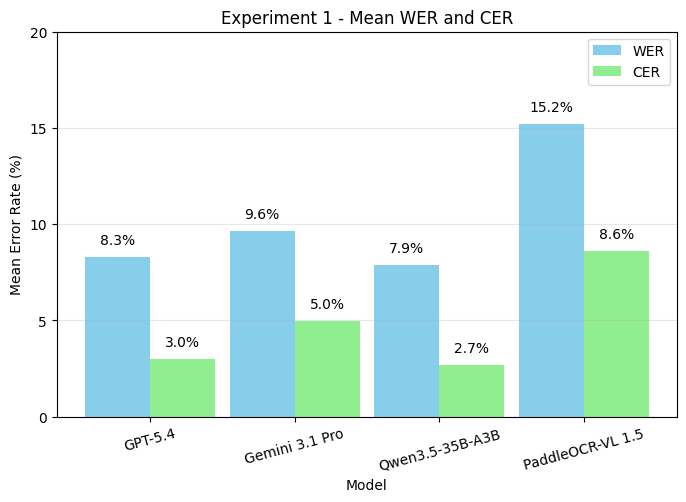

In [41]:
mean_exp1 = (
    df_exp1
    .groupby("Model")[["WER", "CER"]]
    .mean()
    .reset_index()
)

model_order = [
    "GPT-5.4",
    "Gemini 3.1 Pro",
    "Qwen3.5-35B-A3B",
    "PaddleOCR-VL 1.5"
]

mean_exp1["Model"] = pd.Categorical(
    mean_exp1["Model"],
    categories=model_order,
    ordered=True
)

mean_exp1 = mean_exp1.sort_values("Model")

wer_pct = mean_exp1["WER"] * 100
cer_pct = mean_exp1["CER"] * 100

x = np.arange(len(mean_exp1))
width = 0.45

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width / 2,
    wer_pct,
    width,
    color="skyblue",
    label="WER"
)

bars2 = plt.bar(
    x + width / 2,
    cer_pct,
    width,
    color="lightgreen",
    label="CER"
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xticks(
    x,
    mean_exp1["Model"],
    rotation=15
)

plt.xlabel("Model")
plt.ylabel("Mean Error Rate (%)")
plt.title("Experiment 1 - Mean WER and CER")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 20)
plt.yticks(np.arange(0, 21, 5))

os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_1_llm_mean_wer_cer.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

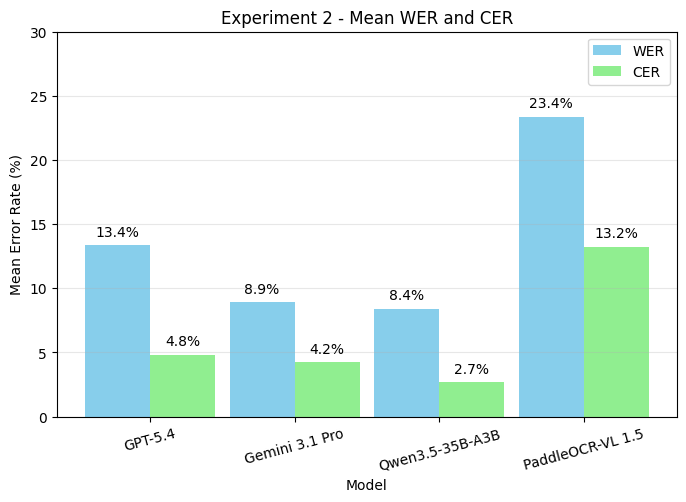

In [42]:
mean_exp2 = (
    df_exp2
    .groupby("Model")[["WER", "CER"]]
    .mean()
    .reset_index()
)

model_order = [
    "GPT-5.4",
    "Gemini 3.1 Pro",
    "Qwen3.5-35B-A3B",
    "PaddleOCR-VL 1.5"
]

mean_exp2["Model"] = pd.Categorical(
    mean_exp2["Model"],
    categories=model_order,
    ordered=True
)

mean_exp2 = mean_exp2.sort_values("Model")

wer_pct = mean_exp2["WER"] * 100
cer_pct = mean_exp2["CER"] * 100

x = np.arange(len(mean_exp2))
width = 0.45

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width / 2,
    wer_pct,
    width,
    color="skyblue",
    label="WER"
)

bars2 = plt.bar(
    x + width / 2,
    cer_pct,
    width,
    color="lightgreen",
    label="CER"
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xticks(
    x,
    mean_exp2["Model"],
    rotation=15
)

plt.xlabel("Model")
plt.ylabel("Mean Error Rate (%)")
plt.title("Experiment 2 - Mean WER and CER")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 30)
plt.yticks(np.arange(0, 31, 5))

os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_2_llm_mean_wer_cer.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

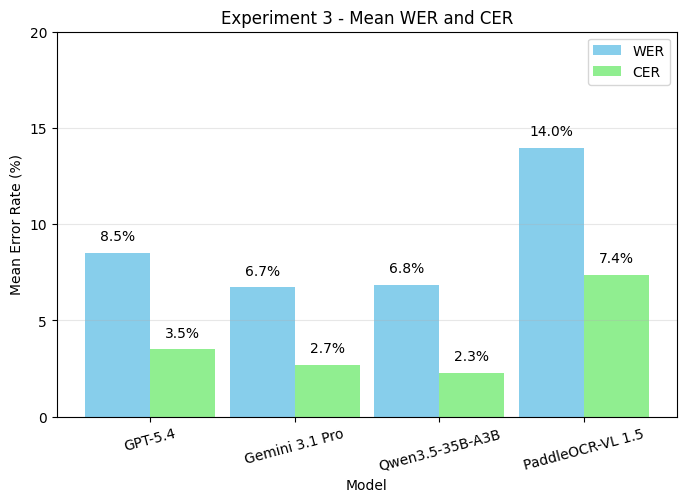

In [43]:
mean_exp3 = (
    df_exp3
    .groupby("Model")[["WER", "CER"]]
    .mean()
    .reset_index()
)

model_order = [
    "GPT-5.4",
    "Gemini 3.1 Pro",
    "Qwen3.5-35B-A3B",
    "PaddleOCR-VL 1.5"
]

mean_exp3["Model"] = pd.Categorical(
    mean_exp3["Model"],
    categories=model_order,
    ordered=True
)

mean_exp3 = mean_exp3.sort_values("Model")

wer_pct = mean_exp3["WER"] * 100
cer_pct = mean_exp3["CER"] * 100

x = np.arange(len(mean_exp3))
width = 0.45

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width / 2,
    wer_pct,
    width,
    color="skyblue",
    label="WER"
)

bars2 = plt.bar(
    x + width / 2,
    cer_pct,
    width,
    color="lightgreen",
    label="CER"
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xticks(
    x,
    mean_exp3["Model"],
    rotation=15
)

plt.xlabel("Model")
plt.ylabel("Mean Error Rate (%)")
plt.title("Experiment 3 - Mean WER and CER")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 20)
plt.yticks(np.arange(0, 21, 5))

os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_3_llm_mean_wer_cer.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

# Based on Models

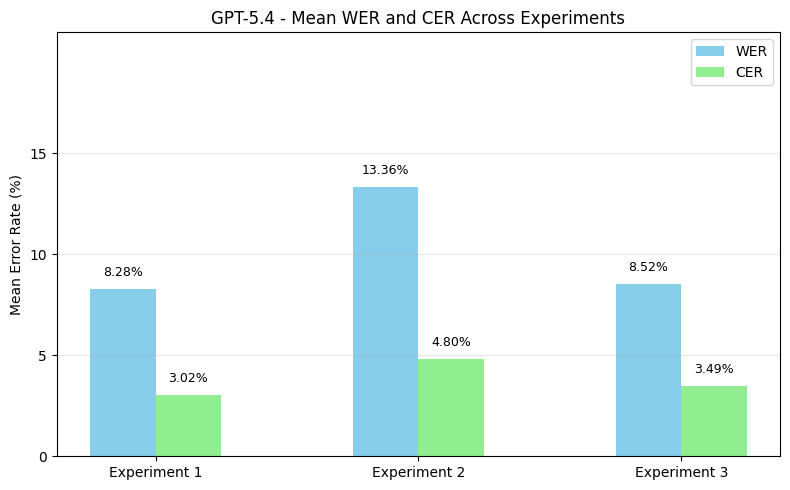

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import os


model_name = "GPT-5.4"

df_model_exp1 = df_exp1[
    df_exp1["Model"] == model_name
]

df_model_exp2 = df_exp2[
    df_exp2["Model"] == model_name
]

df_model_exp3 = df_exp3[
    df_exp3["Model"] == model_name
]


mean_wer = [
    df_model_exp1["WER"].mean() * 100,
    df_model_exp2["WER"].mean() * 100,
    df_model_exp3["WER"].mean() * 100
]

mean_cer = [
    df_model_exp1["CER"].mean() * 100,
    df_model_exp2["CER"].mean() * 100,
    df_model_exp3["CER"].mean() * 100
]


experiments = [
    "Experiment 1",
    "Experiment 2",
    "Experiment 3"
]

x = np.arange(len(experiments))
width = 0.25

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width / 2,
    mean_wer,
    width,
    color="skyblue",
    label="WER"
)

bars2 = plt.bar(
    x + width / 2,
    mean_cer,
    width,
    color="lightgreen",
    label="CER"
)


for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )


plt.xticks(x, experiments)
plt.ylabel("Mean Error Rate (%)")
plt.title("GPT-5.4 - Mean WER and CER Across Experiments")

plt.yticks(np.arange(0, 20, 5))
plt.ylim(0, 21)

plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()

os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir,
        "gpt_5_4_three_experiment_summary.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

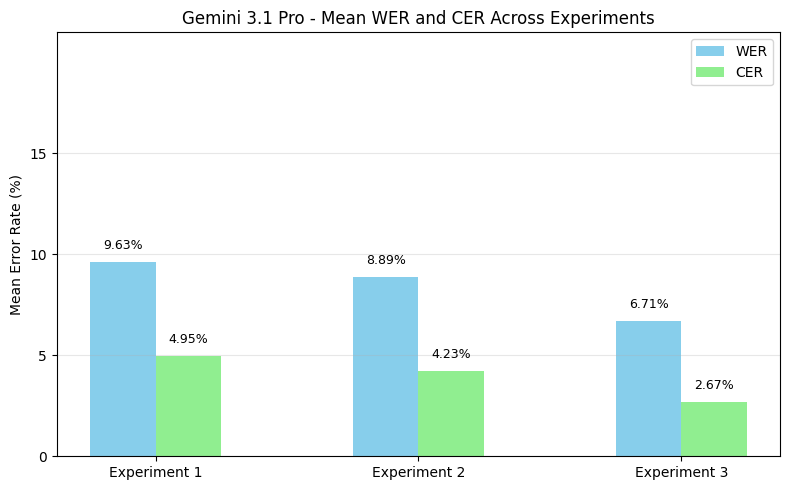

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import os


model_name = "Gemini 3.1 Pro"

df_model_exp1 = df_exp1[
    df_exp1["Model"] == model_name
]

df_model_exp2 = df_exp2[
    df_exp2["Model"] == model_name
]

df_model_exp3 = df_exp3[
    df_exp3["Model"] == model_name
]


mean_wer = [
    df_model_exp1["WER"].mean() * 100,
    df_model_exp2["WER"].mean() * 100,
    df_model_exp3["WER"].mean() * 100
]

mean_cer = [
    df_model_exp1["CER"].mean() * 100,
    df_model_exp2["CER"].mean() * 100,
    df_model_exp3["CER"].mean() * 100
]


experiments = [
    "Experiment 1",
    "Experiment 2",
    "Experiment 3"
]

x = np.arange(len(experiments))
width = 0.25

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width / 2,
    mean_wer,
    width,
    color="skyblue",
    label="WER"
)

bars2 = plt.bar(
    x + width / 2,
    mean_cer,
    width,
    color="lightgreen",
    label="CER"
)


for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )


plt.xticks(x, experiments)
plt.ylabel("Mean Error Rate (%)")
plt.title("Gemini 3.1 Pro - Mean WER and CER Across Experiments")

plt.yticks(np.arange(0, 20, 5))
plt.ylim(0, 21)

plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()

os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir,
        "gemini_3_1_pro_three_experiment_summary.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

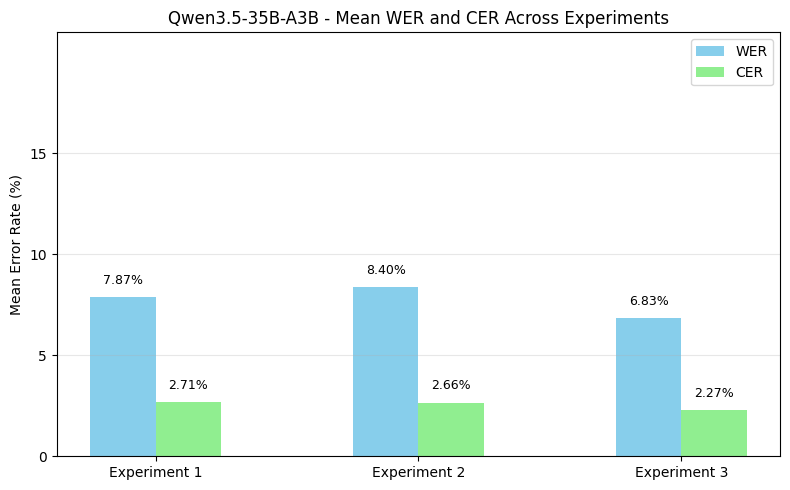

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import os


model_name = "Qwen3.5-35B-A3B"

df_model_exp1 = df_exp1[
    df_exp1["Model"] == model_name
]

df_model_exp2 = df_exp2[
    df_exp2["Model"] == model_name
]

df_model_exp3 = df_exp3[
    df_exp3["Model"] == model_name
]


mean_wer = [
    df_model_exp1["WER"].mean() * 100,
    df_model_exp2["WER"].mean() * 100,
    df_model_exp3["WER"].mean() * 100
]

mean_cer = [
    df_model_exp1["CER"].mean() * 100,
    df_model_exp2["CER"].mean() * 100,
    df_model_exp3["CER"].mean() * 100
]


experiments = [
    "Experiment 1",
    "Experiment 2",
    "Experiment 3"
]

x = np.arange(len(experiments))
width = 0.25

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width / 2,
    mean_wer,
    width,
    color="skyblue",
    label="WER"
)

bars2 = plt.bar(
    x + width / 2,
    mean_cer,
    width,
    color="lightgreen",
    label="CER"
)


for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )


plt.xticks(x, experiments)
plt.ylabel("Mean Error Rate (%)")
plt.title("Qwen3.5-35B-A3B - Mean WER and CER Across Experiments")

plt.yticks(np.arange(0, 20, 5))
plt.ylim(0, 21)

plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()

os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir,
        "qwen_3_5_three_experiment_summary.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

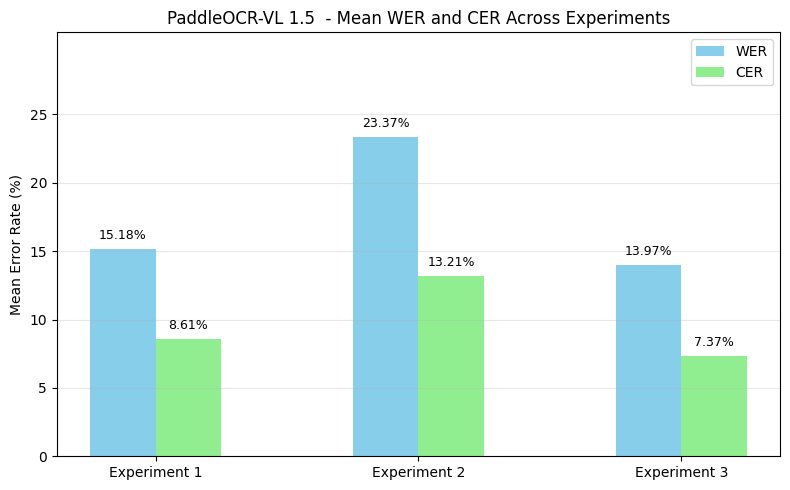

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import os


model_name = "PaddleOCR-VL 1.5"

df_model_exp1 = df_exp1[
    df_exp1["Model"] == model_name
]

df_model_exp2 = df_exp2[
    df_exp2["Model"] == model_name
]

df_model_exp3 = df_exp3[
    df_exp3["Model"] == model_name
]


mean_wer = [
    df_model_exp1["WER"].mean() * 100,
    df_model_exp2["WER"].mean() * 100,
    df_model_exp3["WER"].mean() * 100
]

mean_cer = [
    df_model_exp1["CER"].mean() * 100,
    df_model_exp2["CER"].mean() * 100,
    df_model_exp3["CER"].mean() * 100
]


experiments = [
    "Experiment 1",
    "Experiment 2",
    "Experiment 3"
]

x = np.arange(len(experiments))
width = 0.25

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width / 2,
    mean_wer,
    width,
    color="skyblue",
    label="WER"
)

bars2 = plt.bar(
    x + width / 2,
    mean_cer,
    width,
    color="lightgreen",
    label="CER"
)


for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )


plt.xticks(x, experiments)
plt.ylabel("Mean Error Rate (%)")
plt.title("PaddleOCR-VL 1.5  - Mean WER and CER Across Experiments")

plt.yticks(np.arange(0, 30, 5))
plt.ylim(0, 31)

plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()

os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir,
        "paddleocr_vl_1_5_three_experiment_summary.pdf"
    ),
    bbox_inches="tight"
)

plt.show()